# Imports

In [1]:
# The importing order was changed for readibility.
import os, sys
from random import randint
from pathlib import Path # Not a dependency of original 3DGS, just for this tutorial

import numpy as np
import torch
import open3d as o3d     # Not a dependency of original 3DGS, just for this tutorial
from tqdm import tqdm

from utils.loss_utils import l1_loss, ssim
from gaussian_renderer import render, network_gui
from scene import Scene, GaussianModel
from utils.general_utils import safe_state, get_expon_lr_func
from utils.image_utils import psnr
import uuid
from argparse import ArgumentParser, Namespace
from arguments import ModelParams, PipelineParams, OptimizationParams
from scene.dataset_readers import sceneLoadTypeCallbacks
try:
    from torch.utils.tensorboard import SummaryWriter
    TENSORBOARD_FOUND = True
except ImportError:
    TENSORBOARD_FOUND = False

try:
    from fused_ssim import fused_ssim
    FUSED_SSIM_AVAILABLE = True
except:
    FUSED_SSIM_AVAILABLE = False

try:
    from diff_gaussian_rasterization import SparseGaussianAdam
    SPARSE_ADAM_AVAILABLE = True
except:
    SPARSE_ADAM_AVAILABLE = False

def prepare_output_and_logger(args):    
    if not args.model_path:
        if os.getenv('OAR_JOB_ID'):
            unique_str=os.getenv('OAR_JOB_ID')
        else:
            unique_str = str(uuid.uuid4())
        args.model_path = os.path.join("./output/", unique_str[0:10])
        
    # Set up output folder
    print("Output folder: {}".format(args.model_path))
    os.makedirs(args.model_path, exist_ok = True)
    with open(os.path.join(args.model_path, "cfg_args"), 'w') as cfg_log_f:
        cfg_log_f.write(str(Namespace(**vars(args))))

    # Create Tensorboard writer
    tb_writer = None
    if TENSORBOARD_FOUND:
        tb_writer = SummaryWriter(args.model_path)
    else:
        print("Tensorboard not available: not logging progress")
    return tb_writer



def training_report(tb_writer, iteration, Ll1, loss, l1_loss, elapsed, testing_iterations, scene : Scene, renderFunc, renderArgs, train_test_exp):
    if tb_writer:
        tb_writer.add_scalar('train_loss_patches/l1_loss', Ll1.item(), iteration)
        tb_writer.add_scalar('train_loss_patches/total_loss', loss.item(), iteration)
        tb_writer.add_scalar('iter_time', elapsed, iteration)

    # Report test and samples of training set
    if iteration in testing_iterations:
        torch.cuda.empty_cache()
        validation_configs = ({'name': 'test', 'cameras' : scene.getTestCameras()}, 
                              {'name': 'train', 'cameras' : [scene.getTrainCameras()[idx % len(scene.getTrainCameras())] for idx in range(5, 30, 5)]})

        for config in validation_configs:
            if config['cameras'] and len(config['cameras']) > 0:
                l1_test = 0.0
                psnr_test = 0.0
                for idx, viewpoint in enumerate(config['cameras']):
                    image = torch.clamp(renderFunc(viewpoint, scene.gaussians, *renderArgs)["render"], 0.0, 1.0)
                    gt_image = torch.clamp(viewpoint.original_image.to("cuda"), 0.0, 1.0)
                    if train_test_exp:
                        image = image[..., image.shape[-1] // 2:]
                        gt_image = gt_image[..., gt_image.shape[-1] // 2:]
                    if tb_writer and (idx < 5):
                        tb_writer.add_images(config['name'] + "_view_{}/render".format(viewpoint.image_name), image[None], global_step=iteration)
                        if iteration == testing_iterations[0]:
                            tb_writer.add_images(config['name'] + "_view_{}/ground_truth".format(viewpoint.image_name), gt_image[None], global_step=iteration)
                    l1_test += l1_loss(image, gt_image).mean().double()
                    psnr_test += psnr(image, gt_image).mean().double()
                psnr_test /= len(config['cameras'])
                l1_test /= len(config['cameras'])          
                print("\n[ITER {}] Evaluating {}: L1 {} PSNR {}".format(iteration, config['name'], l1_test, psnr_test))
                if tb_writer:
                    tb_writer.add_scalar(config['name'] + '/loss_viewpoint - l1_loss', l1_test, iteration)
                    tb_writer.add_scalar(config['name'] + '/loss_viewpoint - psnr', psnr_test, iteration)

        if tb_writer:
            tb_writer.add_histogram("scene/opacity_histogram", scene.gaussians.get_opacity, iteration)
            tb_writer.add_scalar('total_points', scene.gaussians.get_xyz.shape[0], iteration)
        torch.cuda.empty_cache()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


# train.py
If you need more specific code review look at [tutorial_train_py.ipynb](tutorial_train_py.ipynb)

This tutorial follows the order in which the program starts after typing  
`python train.py -s your/file`  
on bash

#### Mimic System Arguments

In Line 270 of [`train.py`](train.py#270):
```python
args = parser.parse_args(sys.argv[1:])
```
However, in this tutorial notebook, we do not have system arguments, so:

In [2]:
sys_argv = ["train.py", "-s", "GaussianTest/Test2"]

## Parser Setting
First you set parser inside *train.py* before initializing training method using ArgumentParser

The following code block covers right before calling `training()` function in the `if __name__ == __main__` part of the [`train.py`](train.py#282)

In [3]:
parser = ArgumentParser(description="Training script parameters")
lp = ModelParams(parser)
op = OptimizationParams(parser)
pp = PipelineParams(parser)
parser.add_argument('--ip', type=str, default="127.0.0.1")
parser.add_argument('--port', type=int, default=6009)
parser.add_argument('--debug_from', type=int, default=-1)
parser.add_argument('--detect_anomaly', action='store_true', default=False)
parser.add_argument("--test_iterations", nargs="+", type=int, default=[7_000, 30_000])
parser.add_argument("--save_iterations", nargs="+", type=int, default=[7_000, 30_000])
parser.add_argument("--quiet", action="store_true")
parser.add_argument('--disable_viewer', action='store_true', default=False)
parser.add_argument("--checkpoint_iterations", nargs="+", type=int, default=[])
parser.add_argument("--start_checkpoint", type=str, default=None)

# In Jupyter, parse_known_args avoids runtime arguments such as -f that are injected by the notebook kernel.
# args, _ = parser.parse_known_args([])
args = parser.parse_args(sys_argv[1:])
args.save_iterations.append(args.iterations)

# Convert the parser namespace into the lightweight argument objects used by the training code.
model_args = lp.extract(args)
opt_args = op.extract(args)
pipe_args = pp.extract(args)
# source_path is hardcoded on purpose for this tutorial, but you can change it to your own dataset path.

print("Loaded parser-backed arguments")
print(f"sh_degree     : {model_args.sh_degree    = }" )
print(f"optimizer_type: {opt_args.optimizer_type = }")
print(f"source path   : {model_args.source_path  = }")


Loaded parser-backed arguments
sh_degree     : model_args.sh_degree    = 3
optimizer_type: opt_args.optimizer_type = 'default'
source path   : model_args.source_path  = 'c:\\Users\\chang\\gaussian-splatting\\GaussianTest\\Test2'


## Arguments for `traning()`
Let's observe the following arguments ([Line 282](train.py#282)):
```python
training(lp.extract(args), op.extract(args), pp.extract(args), args.test_iterations, args.save_iterations, args.checkpoint_iterations, args.start_checkpoint, args.debug_from)
```

In [4]:
model_args.__dict__

{'sh_degree': 3,
 'source_path': 'c:\\Users\\chang\\gaussian-splatting\\GaussianTest\\Test2',
 'model_path': '',
 'images': 'images',
 'depths': '',
 'resolution': -1,
 'white_background': False,
 'train_test_exp': False,
 'data_device': 'cuda',
 'eval': False}

## `training` function initialize
```python
def training(model_args: ModelParams, opt_args: OptimizationParams, pipe_args: PipelineParams, testing_iterations: list, saving_iterations: list, checkpoint_iterations: list, checkpoint: str, debug_from: int):
```
After parser is set, inside train.py, `training` function is called, and the process below activates.  
This tutorial explains the code line by line so you can easily figure out what value is used or changed.  
Starts from `train.py` Line 48

In [5]:
first_iter = 0

When you use `prepare_output_and_logger` method, it creates new ouput folder with *unique_str* so you should check your output folder everytime after you run this code

In [6]:
tb_writer = prepare_output_and_logger(model_args)

Output folder: ./output/78940be1-0
Tensorboard not available: not logging progress


In [7]:
print(f"Output path: {model_args.model_path = }")
output_path = Path(model_args.model_path)
input_ply = output_path / "input.ply"
input_ply.unlink(missing_ok=True)

Output path: model_args.model_path = './output/78940be1-0'


In [8]:
gaussians = GaussianModel(model_args.sh_degree, opt_args.optimizer_type)
print("# `GaussianModel` constructed successfully\n")

print("# Output path contents before calling `Scene` constructor:")
for file in output_path.iterdir():
    print(file.absolute())
print()

scene1 = Scene(model_args, gaussians)
print("# GaussianModel initialized successfully\n")

print("# Output path contents before calling `Scene` constructor:")
for file in output_path.iterdir():
    print(file.absolute())

# `GaussianModel` constructed successfully

# Output path contents before calling `Scene` constructor:
c:\Users\chang\gaussian-splatting\output\78940be1-0\cfg_args

Reading camera 25/25
Loading Training Cameras
Loading Test Cameras
Number of points at initialisation :  1768
# GaussianModel initialized successfully

# Output path contents before calling `Scene` constructor:
c:\Users\chang\gaussian-splatting\output\78940be1-0\cameras.json
c:\Users\chang\gaussian-splatting\output\78940be1-0\cfg_args
c:\Users\chang\gaussian-splatting\output\78940be1-0\input.ply


__These are ouputs from # here__  
Reading camera 25/25 # scene.dataset_readers.py Line 76  
Loading Training Cameras # scene.init.py Line 72  
Loading Test Cameras # scene.init.py Line 74    
Number of points at initialisation :  1768 # scene.gaussian_model.py Line 157 (create_from_pcd)

After you run the code above it creates `input.ply` on output folder from `prepare_output_and_logger` which has the same data from [GaussianTest/Test2/sparse/0](GaussianTest/Test2/sparse/0)/points3D.ply 

### Comparing *input.ply* and *points3D.ply*
If you need more detailed code review, look at [tutorial_train_py.ipynb](tutorial_train_py.ipynb) _Chapter Input_

In [9]:
from vispy import app, scene

RFBOutputContext()

CanvasBackend(css_height='600px', css_width='800px')
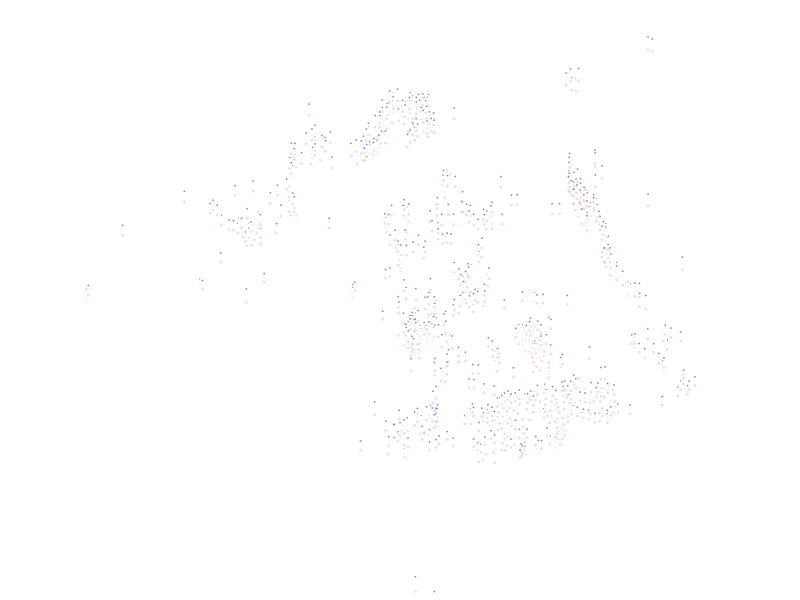

In [62]:
app.use_app('jupyter_rfb')

# 1. 캔버스 및 뷰 생성
canvas = scene.SceneCanvas(keys='interactive', show=True, bgcolor = 'white', size = (800,600))
view = canvas.central_widget.add_view()

# 2. Open3D를 이용해 PLY 파일 로드 (포인트 클라우드)
file_path = input_ply # 파일 경로 수정
pcd = o3d.io.read_point_cloud(file_path)
vertices = np.asarray(pcd.points)

# (선택 사항) 색상 데이터가 파일에 포함되어 있다면 가져오기
colors = np.asarray(pcd.colors) if pcd.has_colors() else 'white'

# 3. 마커(Markers) 객체로 점들 시각화
scatter1 = scene.visuals.Markers()
# size를 조절하여 점의 크기를 변경할 수 있습니다.
scatter1.set_data(vertices,face_color=(1.0,0.0,0.0,0.2), edge_color=None, size=4)
view.add(scatter1)

# 4. points3D.ply 파일 설정
file_path2 = "./GaussianTest/Test2/sparse/0/points3D.ply"
pcd2 = o3d.io.read_point_cloud(file_path2)
vertices2 = np.asarray(pcd2.points)
vertices2[:, 2] += 0.4 # Depth manipulation
scatter2 = scene.visuals.Markers()
scatter2.set_data(vertices2, face_color = (0.0,0.0,1.0,0.8), edge_color = None, size = 3)
view.add(scatter2)

# 5. 카메라 설정
view.camera = 'arcball'
view.camera.set_range(margin=0)
view.camera.scale_factor *= 0.6

# 6. Draw
canvas

### create_from_pcd details
`create_from_pcd` function is called when *Scene* class object is made.  
For more details look at [tutorial_train_py](tutorial_train_py.ipynb) *Chapter create_from_pcd*

In [11]:
print(f"gaussians._exposure length: {len(gaussians._exposure)}")
print(f"gaussians._exposure: {gaussians._exposure}")

gaussians._exposure length: 25
gaussians._exposure: Parameter containing:
tensor([[[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.]],

        [[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.]],

        [[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.]],

        [[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.]],

        [[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.]],

        [[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.]],

        [[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.]],

        [[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.]],

        [[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.]],

        [[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.]],

        [[1., 0., 0., 0.],
         [0., 1., 0., 0.],
         [0., 0., 1., 0.]],

        [[1.,

## Training Setup
This is where you setup training environment  
It sets the `gaussians.optimizer`, `gaussians.exposure_optimizer` with `torch.optim.Adam`.  
And sets `gaussians.xyz_scheduler_args`, `gaussians.exposrue_scheduler_args` with function `helper()`

In [12]:
gaussians.training_setup(opt_args)

### Training Setup details

In [13]:
print(f"Optimizer Type: {gaussians.optimizer_type}","\n")
print(f"Optimizer: {gaussians.optimizer}", "\n")
print(f"Exposure_Optimizer: {gaussians.exposure_optimizer}" )

Optimizer Type: default 

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-15
    foreach: None
    fused: None
    lr: 0.0008126943139359355
    maximize: False
    name: xyz
    weight_decay: 0

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-15
    foreach: None
    fused: None
    lr: 0.0025
    maximize: False
    name: f_dc
    weight_decay: 0

Parameter Group 2
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-15
    foreach: None
    fused: None
    lr: 0.000125
    maximize: False
    name: f_rest
    weight_decay: 0

Parameter Group 3
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    ep

In [14]:
print(f"{type(gaussians.xyz_scheduler_args) = }")
print(f"{type(gaussians.exposure_scheduler_args) = }")

type(gaussians.xyz_scheduler_args) = <class 'function'>
type(gaussians.exposure_scheduler_args) = <class 'function'>


`get_expon_lr_func` returns `helper` function,  
so when you print what variable `gaussians.xyz_scheduler_args`, `gaussians.exposure_scheduler_args` have, it prints address where helper function is located  

For more details, look at [tutorial_train_py](tutorial_train_py.ipynb) *Chapter Training Setup/get_expon_lr_func/How it works* 

__For line 53~55, since we don't use parameter *checkpoint* we will skip this part__
## Getting ready before starting training

In [16]:
bg_color = [1, 1, 1] if model_args.white_background else [0, 0, 0]
background = torch.tensor(bg_color, dtype=torch.float32, device="cuda")
print(f"model_args.white_background: {model_args.white_background}")
print(f"bg_color: {bg_color}")
print(f"Background color: {background}")


model_args.white_background: False
bg_color: [0, 0, 0]
Background color: tensor([0., 0., 0.], device='cuda:0')


In [17]:
iter_start = torch.cuda.Event(enable_timing = True)
iter_end = torch.cuda.Event(enable_timing = True)

In [18]:
use_sparse_adam = opt_args.optimizer_type == "sparse_adam" and SPARSE_ADAM_AVAILABLE 
print(f"since {opt_args.optimizer_type} is false, use_sparse_adam is {use_sparse_adam}")

since default is false, use_sparse_adam is False


In [19]:
print(f"opt_args.depth_l1_weight_init: {opt_args.depth_l1_weight_init}, opt_args.depth_l1_weight_final: {opt_args.depth_l1_weight_final}, opt_args.iterations: {opt_args.iterations}")
depth_l1_weight = get_expon_lr_func(opt_args.depth_l1_weight_init, opt_args.depth_l1_weight_final, max_steps=opt_args.iterations)
print(f"depth_l1_weight: {depth_l1_weight}")

opt_args.depth_l1_weight_init: 1.0, opt_args.depth_l1_weight_final: 0.01, opt_args.iterations: 30000
depth_l1_weight: <function get_expon_lr_func.<locals>.helper at 0x00000258D6C43550>


In [20]:
print(gaussians.xyz_gradient_accum)

tensor([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], device='cuda:0')


In [21]:
viewpoint_stack = scene1.getTrainCameras().copy()
viewpoint_indices = list(range(len(viewpoint_stack)))
print(f"viewpoint_stack: {viewpoint_stack}")
print(f"viewpoint_stack inside value: {viewpoint_stack[0].T}")
print(f"viewpoint_stack inside value: {viewpoint_stack[1].T}")
print(f"viewpoint_indices: {viewpoint_indices}")

viewpoint_stack: [Camera(), Camera(), Camera(), Camera(), Camera(), Camera(), Camera(), Camera(), Camera(), Camera(), Camera(), Camera(), Camera(), Camera(), Camera(), Camera(), Camera(), Camera(), Camera(), Camera(), Camera(), Camera(), Camera(), Camera(), Camera()]
viewpoint_stack inside value: [ 1.02718846 -2.57835089  1.82616108]
viewpoint_stack inside value: [ 0.56341554 -2.50232877  1.53516351]
viewpoint_indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


In [22]:
ema_loss_for_log = 0.0
ema_Ll1depth_for_log = 0.0

In [23]:
print(f"First iteration: {first_iter}, Last iteration: {opt_args.iterations}")
progress_bar = tqdm(range(first_iter, opt_args.iterations), desc="Training progress")

First iteration: 0, Last iteration: 30000


Training progress:   0%|          | 0/30000 [00:00<?, ?it/s]

In [24]:
first_iter += 1

## Start training  
It starts with the code 
```python
for iteration in range(first_iter, opt.iterations + 1):
```
But we want to see what happens inside the loop.  
And from line 74~87 the code is trying to connect to viewer so it doesn't matter whether this works  or not.  
So, we are going to start from train.py Line 89  

Let's assume that we are going through 1 loop of training.

In [25]:
iter_start.record()

In [26]:
iteration = first_iter
print(f"gaussians.pretrained_exposures: {gaussians.pretrained_exposures}")
a = gaussians.exposure_optimizer.param_groups[0]['lr']
b = gaussians.optimizer.param_groups[0]['lr']
print(f"gaussians.exposure_optimizer's lr: {a}")
print(f"gaussians.optimizer's lr: {b}")
print(f"gaussians.optimizer.param_groups[0]['name']: {gaussians.optimizer.param_groups[0]['name']}")

gaussians.pretrained_exposures: None
gaussians.exposure_optimizer's lr: 0.001
gaussians.optimizer's lr: 0.0008126943139359355
gaussians.optimizer.param_groups[0]['name']: xyz


In [27]:
gaussians.update_learning_rate(iteration)

np.float64(0.0008125694239671021)

In [28]:
print(gaussians.xyz_gradient_accum)

tensor([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], device='cuda:0')


In [29]:
print(f"gaussians.exposure_optimizer's lr: {gaussians.exposure_optimizer.param_groups[0]['lr']}")
print(f"gaussians.optimizer's lr: {gaussians.optimizer.param_groups[0]['lr']}")
print(f"gaussians.exposure_optimizer's lr's deviation: {a - gaussians.exposure_optimizer.param_groups[0]['lr']}")
print(f"gaussians.optimizer's lr's deviation: {b - gaussians.optimizer.param_groups[0]['lr']}")

gaussians.exposure_optimizer's lr: 0.00999923250108991
gaussians.optimizer's lr: 0.0008125694239671021
gaussians.exposure_optimizer's lr's deviation: -0.008999232501089909
gaussians.optimizer's lr's deviation: 1.2488996883343838e-07


In [30]:
# Every 1000 its we increase the levels of SH up to a maximum degree
print(f"gaussians.active_sh_degree: {gaussians.active_sh_degree}, gaussians.max_sh_degree: {gaussians.max_sh_degree}")
if iteration % 1000 == 0:
    gaussians.oneupSHdegree()
print(f"gaussians.active_sh_degree after oneupSHdegree: {gaussians.active_sh_degree}")

gaussians.active_sh_degree: 0, gaussians.max_sh_degree: 3
gaussians.active_sh_degree after oneupSHdegree: 0


In [31]:
# Pick a random Camera
rand_idx = randint(0, len(viewpoint_indices) - 1) # code in train.py
print(f"rand_idx: {rand_idx}")
viewpoint_cam = viewpoint_stack.pop(rand_idx) # code in train.py
print(f"viewpoint_cam: {viewpoint_cam.uid}")
print(f"viewpoint_cam.colmap_id: {viewpoint_cam.colmap_id}")
print(f"viewpoint_cam.R: {viewpoint_cam.R}")
print(f"viewpoint_cam.T: {viewpoint_cam.T}")
print(f"viewpoint_cam.FoVx: {viewpoint_cam.FoVx}, viewpoint_cam.FoVy: {viewpoint_cam.FoVy}")
print(f"viewpoint_cam.image_name: {viewpoint_cam.image_name}")
vind = viewpoint_indices.pop(rand_idx) # code in train.py
print(f"vind: {vind}")

rand_idx: 16
viewpoint_cam: 16
viewpoint_cam.colmap_id: 1
viewpoint_cam.R: [[-0.99853865 -0.04735733  0.02603549]
 [ 0.03759296 -0.26258239  0.96417699]
 [-0.03882439  0.96374674  0.26397897]]
viewpoint_cam.T: [ 1.66645276e-03 -3.53759195e+00  2.54733802e+00]
viewpoint_cam.FoVx: 0.602981540771676, viewpoint_cam.FoVy: 1.0060968822522376
viewpoint_cam.image_name: 0015.jpg
vind: 16


In [32]:
# Render
print(f"args.debug_from: {args.debug_from}, iteration: {iteration}")
if (iteration - 1) == args.debug_from: # code in train.py
    pipe_args.debug = True
print(f"pipe_args.debug: {pipe_args.debug}")

args.debug_from: -1, iteration: 1
pipe_args.debug: False


In [33]:
print(f"opt_args.random_background: {opt_args.random_background}")
bg = torch.rand((3), device="cuda") if opt_args.random_background else background # code in train.py
print(f"bg: {bg}")

opt_args.random_background: False
bg: tensor([0., 0., 0.], device='cuda:0')


In [34]:
render_pkg = render(viewpoint_cam, gaussians, pipe_args, bg, use_trained_exp=model_args.train_test_exp, separate_sh=SPARSE_ADAM_AVAILABLE)
image, viewspace_point_tensor, visibility_filter, radii = render_pkg["render"], render_pkg["viewspace_points"], render_pkg["visibility_filter"], render_pkg["radii"]

In [35]:
print(gaussians.xyz_gradient_accum)

tensor([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], device='cuda:0')


In [36]:
print(f"image.shape: {image.shape}, viewspace_point_tensor.shape: {viewspace_point_tensor.shape}, visibility_filter.shape: {visibility_filter.shape}, radii.shape: {radii.shape}")

image.shape: torch.Size([3, 1846, 1041]), viewspace_point_tensor.shape: torch.Size([1768, 3]), visibility_filter.shape: torch.Size([908, 1]), radii.shape: torch.Size([1768])


In [37]:
print(viewpoint_cam.alpha_mask != None)
print(f"viewpoint_cam.alpha_mask.shape: {viewpoint_cam.alpha_mask.shape}")

True
viewpoint_cam.alpha_mask.shape: torch.Size([1, 1846, 1041])


In [38]:
print(image[0])

tensor([[0.1611, 0.1615, 0.1618,  ..., 0.0578, 0.0563, 0.0563],
        [0.1631, 0.1635, 0.1638,  ..., 0.0579, 0.0564, 0.0564],
        [0.1651, 0.1655, 0.1667,  ..., 0.0580, 0.0580, 0.0565],
        ...,
        [0.0991, 0.0991, 0.0992,  ..., 0.1315, 0.1319, 0.1322],
        [0.0990, 0.0990, 0.0990,  ..., 0.1316, 0.1320, 0.1324],
        [0.0989, 0.0989, 0.0989,  ..., 0.1317, 0.1321, 0.1325]],
       device='cuda:0', grad_fn=<SelectBackward0>)


In [39]:
if viewpoint_cam.alpha_mask is not None:
            alpha_mask = viewpoint_cam.alpha_mask.cuda()
            image *= alpha_mask

In [40]:
print(image[0])

tensor([[0.1611, 0.1615, 0.1618,  ..., 0.0578, 0.0563, 0.0563],
        [0.1631, 0.1635, 0.1638,  ..., 0.0579, 0.0564, 0.0564],
        [0.1651, 0.1655, 0.1667,  ..., 0.0580, 0.0580, 0.0565],
        ...,
        [0.0991, 0.0991, 0.0992,  ..., 0.1315, 0.1319, 0.1322],
        [0.0990, 0.0990, 0.0990,  ..., 0.1316, 0.1320, 0.1324],
        [0.0989, 0.0989, 0.0989,  ..., 0.1317, 0.1321, 0.1325]],
       device='cuda:0', grad_fn=<SelectBackward0>)


Values didn't change so I checked `viewpoint_cam.alpha_mask[0]`

In [41]:
print(f"viewpoint_cam.alpha_mask: {viewpoint_cam.alpha_mask[0]}")

viewpoint_cam.alpha_mask: tensor([[1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        ...,
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.]], device='cuda:0')


## Computing Loss

In [42]:
# Loss
gt_image = viewpoint_cam.original_image.cuda()
print(gt_image[0].shape)

torch.Size([1846, 1041])


In [43]:
print(image[0].shape)

torch.Size([1846, 1041])


In [44]:
Ll1 = l1_loss(image, gt_image)
print(Ll1)

tensor(0.2774, device='cuda:0', grad_fn=<MeanBackward0>)


In [45]:
FUSED_SSIM_AVAILABLE

True

In [46]:
if FUSED_SSIM_AVAILABLE: # this works
    ssim_value = fused_ssim(image.unsqueeze(0), gt_image.unsqueeze(0))
else:
    ssim_value = ssim(image, gt_image)

In [47]:
print(ssim_value)

tensor(0.5638, device='cuda:0', grad_fn=<MeanBackward0>)


In [48]:
loss = (1.0 - opt_args.lambda_dssim) * Ll1 + opt_args.lambda_dssim * (1.0 - ssim_value)

In [49]:
print(loss)

tensor(0.3092, device='cuda:0', grad_fn=<AddBackward0>)


In [50]:
print(f"depth_l1_weight(iteration): {depth_l1_weight(iteration)}")
print(f"viewpoint_cam.depthreliable: {viewpoint_cam.depth_reliable}")

depth_l1_weight(iteration): 0.9998465061085267
viewpoint_cam.depthreliable: False


In [51]:
print(gaussians.xyz_gradient_accum)

tensor([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], device='cuda:0')


In [52]:
# Depth regularization
Ll1depth_pure = 0.0
if depth_l1_weight(iteration) > 0 and viewpoint_cam.depth_reliable:
    invDepth = render_pkg["depth"]
    mono_invdepth = viewpoint_cam.invdepthmap.cuda()
    depth_mask = viewpoint_cam.depth_mask.cuda()

    Ll1depth_pure = torch.abs((invDepth  - mono_invdepth) * depth_mask).mean()
    Ll1depth = depth_l1_weight(iteration) * Ll1depth_pure 
    loss += Ll1depth
    Ll1depth = Ll1depth.item()
else: # this works
    Ll1depth = 0


In [53]:
loss.backward()

In [54]:
iter_end.record()

# while torch.no_grad() start

In [55]:
print(loss.item())

0.30915892124176025


In [56]:
# Progress bar
ema_loss_for_log = 0.4 * loss.item() + 0.6 * ema_loss_for_log
ema_Ll1depth_for_log = 0.4 * Ll1depth + 0.6 * ema_Ll1depth_for_log

if iteration % 10 == 0:
    progress_bar.set_postfix({"Loss": f"{ema_loss_for_log:.{7}f}", "Depth Loss": f"{ema_Ll1depth_for_log:.{7}f}"})
    progress_bar.update(10)
if iteration == opt_args.iterations:
    progress_bar.close()

In [57]:
# Log and save
training_report(tb_writer, iteration, Ll1, loss, l1_loss, iter_start.elapsed_time(iter_end), args.test_iterations, scene, render, (pipe_args, background, 1., SPARSE_ADAM_AVAILABLE, None, model_args.train_test_exp), model_args.train_test_exp)
if (iteration in args.save_iterations):
    print("\n[ITER {}] Saving Gaussians".format(iteration))
    scene.save(iteration)

In [58]:
print(iteration < opt_args.densify_until_iter)

True


In [59]:
# Densification
if iteration < opt_args.densify_until_iter:
    # Keep track of max radii in image-space for pruning
    gaussians.max_radii2D[visibility_filter] = torch.max(gaussians.max_radii2D[visibility_filter], radii[visibility_filter])
    gaussians.add_densification_stats(viewspace_point_tensor, visibility_filter)
    print(f"gaussians.xyz_gradient_accum: {gaussians.xyz_gradient_accum}")

    if iteration > opt_args.densify_from_iter and iteration % opt_args.densification_interval == 0:
        size_threshold = 20 if iteration > opt_args.opacity_reset_interval else None
        gaussians.densify_and_prune(opt_args.densify_grad_threshold, 0.005, scene.cameras_extent, size_threshold, radii)

    if iteration % opt_args.opacity_reset_interval == 0 or (model_args.white_background and iteration == opt_args.densify_from_iter):
        gaussians.reset_opacity()

gaussians.xyz_gradient_accum: tensor([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], device='cuda:0')


In [60]:
print(render_pkg["visibility_filter"].shape)
print(type(visibility_filter))
print(type(gaussians.max_radii2D))
print(opt_args.densify_from_iter)
print(opt_args.opacity_reset_interval)
print(gaussians.xyz_gradient_accum)
print(gaussians.percent_dense)

torch.Size([908, 1])
<class 'torch.Tensor'>
<class 'torch.Tensor'>
500
3000
tensor([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]], device='cuda:0')
0.01


In [61]:
# Optimizer step
if iteration < opt_args.iterations:
    gaussians.exposure_optimizer.step()
    gaussians.exposure_optimizer.zero_grad(set_to_none = True)
    if use_sparse_adam:
        visible = radii > 0
        gaussians.optimizer.step(visible, radii.shape[0])
        gaussians.optimizer.zero_grad(set_to_none = True)
    else:
        gaussians.optimizer.step()
        gaussians.optimizer.zero_grad(set_to_none = True)

if (iteration in args.checkpoint_iterations):
    print("\n[ITER {}] Saving Checkpoint".format(iteration))
    torch.save((gaussians.capture(), iteration), scene.model_path + "/chkpnt" + str(iteration) + ".pth")